# ANÁLISIS DE ARTISTAS EN SPOTIFY Y YOUTUBE

# Descripción de Columnas del Dataset

| Columna             | Descripción |
|---------------------|-------------|
| **Artist**         | Nombre del artista o banda que interpreta la canción. |
| **Url_spotify**    | URL de la canción en Spotify. |
| **Track**          | Nombre de la canción. |
| **Album**          | Nombre del álbum en el que se encuentra la canción. |
| **Album_type**     | Tipo de álbum (por ejemplo, "album", "single", "compilation"). |
| **Uri**            | URI de Spotify que identifica de manera única la canción. |
| **Danceability**   | Medida (de 0 a 1) que indica qué tan bailable es la canción, basada en ritmo, estabilidad del tempo y beat. |
| **Energy**        | Medida (de 0 a 1) que representa la intensidad y actividad de la canción (valores altos corresponden a canciones más dinámicas). |
| **Key**           | Tono musical de la canción representado en un número entero (0 = Do, 1 = Do#, ..., 11 = Si). |
| **Loudness**      | Nivel de volumen de la canción en decibelios (dB). |
| **Speechiness**   | Medida (de 0 a 1) que indica la cantidad de palabras habladas en la canción (valores altos indican que es más una grabación hablada que cantada). |
| **Acousticness**  | Medida (de 0 a 1) que evalúa la probabilidad de que la canción sea acústica (valores altos indican mayor presencia de instrumentos acústicos). |
| **Instrumentalness** | Medida (de 0 a 1) que indica la presencia de voces en la canción (valores altos indican menor presencia vocal). |
| **Liveness**      | Medida (de 0 a 1) que estima si la canción fue grabada en vivo (valores altos sugieren una grabación en directo). |
| **Valence**       | Medida (de 0 a 1) que describe la positividad musical de la canción (valores altos corresponden a canciones más alegres). |
| **Tempo**        | Velocidad de la canción en beats per minute (BPM). |
| **Duration_ms**  | Duración de la canción en milisegundos. |
| **Url_youtube**  | URL de la canción en YouTube. |
| **Title**        | Título de la canción en YouTube. |
| **Channel**      | Nombre del canal de YouTube donde está publicada la canción. |
| **Views**        | Número de visualizaciones de la canción en YouTube. |
| **Likes**        | Número de "me gusta" en YouTube. |
| **Comments**     | Número de comentarios en YouTube. |
| **Description**  | Descripción proporcionada en el video de YouTube. |
| **Licensed**     | Indica si el contenido en YouTube está licenciado oficialmente (True/False). |
| **official_video** | Indica si el video en YouTube es el video oficial del artista (True/False). |
| **Stream**       | Número total de reproducciones de la canción en plataformas de streaming. |



## Ejercicio 1: Limpieza de Datos

Identifica las columnas con valores nulos y sigue estas reglas:

* Si una columna tiene más del 3% de valores nulos, elimínala.
* Para columnas numéricas con valores nulos, reemplázalos por la mediana.
* Para columnas categóricas con valores nulos, reemplázalos por el valor más frecuente.
* Cambia los tipos de datos de las siguientes columnas:
* Convierte "Key", "Tempo", "Views", "Likes", "Comments", y "Stream" a tipo entero.
* Guarda el dataset limpio en una variable llamada data_cleaned.

In [28]:
import pandas as pd

df_sy = pd.read_csv('./datasets/Spotify_Youtube.csv')

In [30]:
# 1. LIMPIEZA DE DATOS

# 1.1. si alguna columna tiene más de 3% de valores nulos, eliminarla
nulos = df_sy.isnull().sum()
col_eliminar = nulos[nulos > (0.03 * len(df_sy))].index
data_cleaned = df_sy.drop(columns=col_eliminar)

# 1.2. reemplazar con la mediana las columnas numéricas con valores nulos
df_sy_num = data_cleaned.select_dtypes(include=['int64','float64'])
for col in df_sy_num:
    if data_cleaned[col].isnull().sum() > 0:
        data_cleaned[col] = data_cleaned[col].fillna(df_sy_num[col].median())

# 1.3. reemplazar con el valor más frecuente las columnas categóricas con valores nulos
df_sy_cat = data_cleaned.select_dtypes(include=['str','object'])
for col in df_sy_cat:
    if data_cleaned[col].isnull().sum() > 0:
        data_cleaned[col] = data_cleaned[col].fillna(df_sy_cat[col].mode()[0])

# 1.4. cambio de tipo de datos (a entero) para "Key", "Tempo", "Views", "Likes", "Comments", y "Stream"
cols_to_int = ['Key','Tempo','Views','Likes','Comments','Stream']
for col in cols_to_int:
    if col in data_cleaned.columns:
        data_cleaned[col] = data_cleaned[col].astype('int64', errors='ignore')

## Ejercicio 2: Análisis Descriptivo del dataset Limpio

Utilizando data_cleaned, calcula las siguientes estadísticas descriptivas para las columnas "Views", "Likes", "Comments", y "Stream":

* Media, mediana, desviación estándar, mínimo, y máximo.
* Guarda estas estadísticas en un dataFrame llamado descriptive_stats.
* Filtra todas las canciones con más de 500 millones de visualizaciones ("Views") y guarda este subconjunto en top_youtube.

In [33]:
# EJERCICIO 2: ANÁLISIS DESCRIPTIVO DEL DATASET LIMPIO (data_cleaned)

# columnas: "Views", "Likes", "Comments", y "Stream"
# 2.1. Media, mediana, desviación estándar, mínimo y máximo
# 2.2. guardar las estadísticas en un df llamado descriptive_stats
descriptive_stats = data_cleaned[['Views','Likes','Comments','Stream']].describe()
print(descriptive_stats)

# 2.3. guardar en top_youtube las canciones con +500 millones de vistas
top_youtube = data_cleaned[data_cleaned['Views'] > 500000000]

              Views         Likes      Comments        Stream
count  2.071800e+04  2.071800e+04  2.071800e+04  2.071800e+04
mean   9.213575e+07  6.492700e+05  2.685321e+04  1.335440e+08
std    2.717686e+08  1.767896e+06  1.906038e+05  2.411317e+08
min    0.000000e+00  0.000000e+00  0.000000e+00  6.574000e+03
25%    1.950563e+06  2.302175e+04  5.420000e+02  1.825666e+07
50%    1.450110e+07  1.244810e+05  3.277000e+03  4.968298e+07
75%    6.749228e+07  4.996608e+05  1.372900e+04  1.337912e+08
max    8.079649e+09  5.078865e+07  1.608314e+07  3.386520e+09


## Ejercicio 3: Creación de Nuevas Columnas y Análisis por Grupo

**Utiliza el dataFrame top_youtube.** 

* Crea una nueva columna llamada "Likes_to_Views" que represente la proporción de "Likes" respecto a "Views", con dos decimales.
* Agrupa las canciones de top_youtube por "Album_type" y calcula:
* Promedio y mediana de "Energy" y "Danceability".
* Total de "Views" y "Stream" por tipo de álbum.
* Guarda el resultado de la agrupación en un nuevo dataFrame llamado album_analysis.

In [37]:
top_youtube['Likes_to_Views'] = (top_youtube['Likes'] / top_youtube['Views']).round(2)

album_analysis = top_youtube.groupby('Album_type').agg({
    'Energy':['mean','median'],
    'Danceability':['mean','median'],
    'Views':'sum',
    'Stream':'sum',
}).reset_index()

## Ejercicio 4: Identificación de Canciones con Baja Proporción de Likes

**Utiliza el dataFrame top_youtube.**

* Filtra todas las canciones cuya proporción "Likes_to_Views" sea menor a 0.01.
* Guarda este subconjunto en un dataFrame llamado low_likes.
* Dentro de low_likes, calcula el número total de canciones por "Album_type" y guarda el resultado en un dataFrame llamado low_likes_summary.

In [39]:
low_likes = top_youtube[top_youtube['Likes_to_Views'] < 0.01]

low_likes_summary = low_likes.groupby('Album_type').size().reset_index(name='count')

## Ejercicio 5: Análisis de Tendencias de Canciones con Baja Proporción de Likes

**Utiliza el dataFrame low_likes.**

Crea un gráfico de líneas que muestre:

* La relación promedio entre "Stream" y "Energy" para las canciones en low_likes.
* En el eje X: "Energy".
* En el eje Y: promedio de "Stream".
* Diferencia los tipos de álbum ("Album_type") con colores en el gráfico.
* Asegúrate de incluir título, leyendas, y etiquetas de ejes.

C:\Users\User\AppData\Local\Temp\ipykernel_13340\3410735342.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Album_type')


<Axes: title={'center': 'Relación entre Stream y Energy en low_likes'}, xlabel='Energy', ylabel='Stream'>

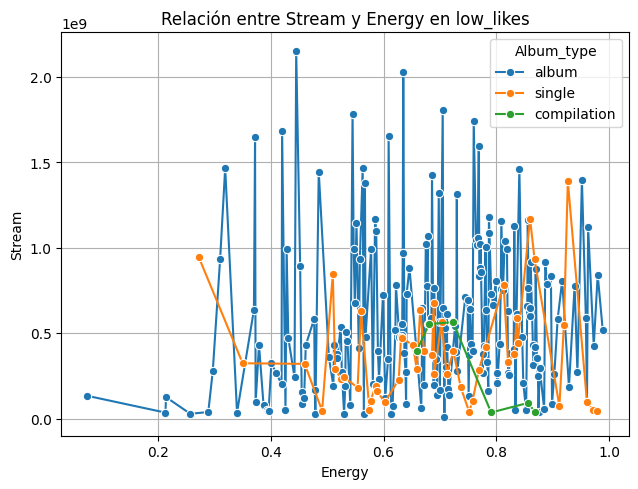

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Promedio de "Stream" por "Energy" y "Album_type" en el subconjunto `low_likes`
trend = low_likes.groupby(['Energy','Album_type']).agg({'Stream':'mean'}).reset_index()

plt.title('Relación entre Stream y Energy en low_likes')
plt.legend(title='Album_type')
plt.grid(True)
plt.tight_layout()
sns.lineplot(data=trend, x='Energy', y='Stream', hue='Album_type', marker='o')

## Ejercicio 6: Rango de valores de danceability

**Utiliza el dataFrame low_likes.**

* Muestra el rango de valores existente promedio de danceability para los diferentes tipos de canciones en spotify (columna Album_type) en un mapa de calor.
* Asegúrate de incluir una barra de colores, etiquetas de ejes, y un título descriptivo.

<Axes: title={'center': 'Rango de valores promedio de Danceability según el tipo de canción'}, ylabel='Album_type'>

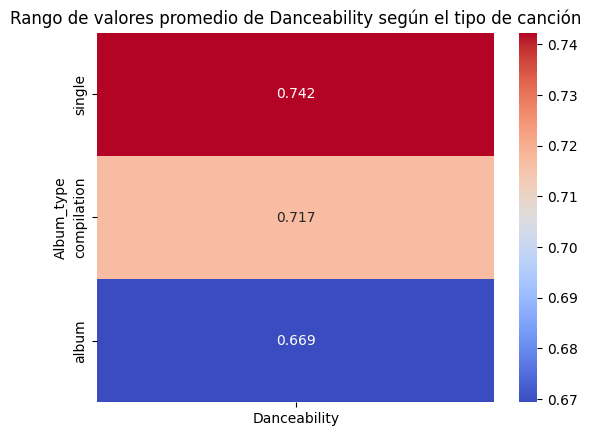

In [146]:
heatmap_data = low_likes.groupby('Album_type', as_index=False)['Danceability'].mean().set_index('Album_type')

heatmap_data = heatmap_data.sort_values(by='Danceability', ascending=False)

plt.title('Rango de valores promedio de Danceability según el tipo de canción')
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.3f')

## Ejercicio 7: Análisis de Artistas

**Utiliza el dataFrame low_likes.**

* Identifica los tres artistas con el mayor total de "Stream" en este subconjunto.
* Presenta un dataFrame con el nombre del artista y el total correspondiente, ordenados de mayor a menor.
* Genera un gráfico de barras que compare estos totales entre los artistas identificados, en el eje X debe ir la variable stream y en el eje Y la variable Artist, para ello utiliza el método barplot() de la librería seaborn.